In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

# Set working directory to project root
if os.path.basename(os.getcwd()) == "Figures":
    os.chdir("..")
print("Working directory:", os.getcwd())

# ---------------------------------------------------------------------------
# Data paths (relative to project root)
# ---------------------------------------------------------------------------
DATA_ROOT = "./data"

CSV_SOYBEAN = f'{DATA_ROOT}/Soybean_Measured vs simulated_US_NE.csv'
CSV_MAIZE   = f'{DATA_ROOT}/Maize_Measured vs simulated_US_NE.csv'

# Verify files exist
for path in [CSV_SOYBEAN, CSV_MAIZE]:
    status = "OK" if os.path.exists(path) else "MISSING"
    print(f"  [{status}] {path}")

Working directory: c:\BioCro_DSSAT_WOFOST_Egorov_etal_paper-main
  [OK] ./data/Soybean_Measured vs simulated_US_NE.csv
  [OK] ./data/Maize_Measured vs simulated_US_NE.csv


In [ ]:
def plot_yield_comparison(csv_path, simulated_col, title,
                         color='green', xlim=7, ylim=7):
    """
    Scatter plot of measured vs simulated yield with RMSE / nRMSE.

    Parameters
    ----------
    csv_path      : path to the CSV file.
    simulated_col : column name for simulated yield.
    title         : plot title (model name).
    color         : marker colour for both irrigated (filled) and rainfed (hollow).
    xlim, ylim    : axis upper limits (lower is always 0).
    """
    df = pd.read_csv(csv_path)
    df['irg'] = df['irg'].str.strip()
    filtered = df.dropna(subset=['OBS yield', simulated_col, 'irg'])

    measured  = filtered['OBS yield'].to_numpy()
    simulated = filtered[simulated_col].to_numpy()
    irrigation = filtered['irg'].to_numpy()

    rmse  = np.sqrt(mean_squared_error(measured, simulated))
    nrmse = (rmse / np.mean(measured)) * 100

    fig, ax = plt.subplots(figsize=(6, 6))

    for irg in np.unique(irrigation):
        mask = irrigation == irg
        if irg == 'irrigated':
            ax.scatter(measured[mask], simulated[mask],
                       color=color, s=100, label='Irrigated', edgecolors='none')
        elif irg == 'rainfed':
            ax.scatter(measured[mask], simulated[mask],
                       facecolors='none', edgecolors=color, s=100, label='Rainfed')

    # 1:1 line
    ax.plot([0, max(xlim, ylim)], [0, max(xlim, ylim)], color='black')

    ax.set_xlabel('Measured yield (t/ha)', fontsize=16)
    ax.set_ylabel('Simulated yield (t/ha)', fontsize=16)
    ax.set_title(title, fontsize=16)
    ax.set_xlim(0, xlim)
    ax.set_ylim(0, ylim)

    legend = ax.legend(fontsize=12)
    legend.set_title(f'RMSE={rmse:.2f}\nnRMSE={nrmse:.2f}%', prop={'size': 12})

    plt.show()

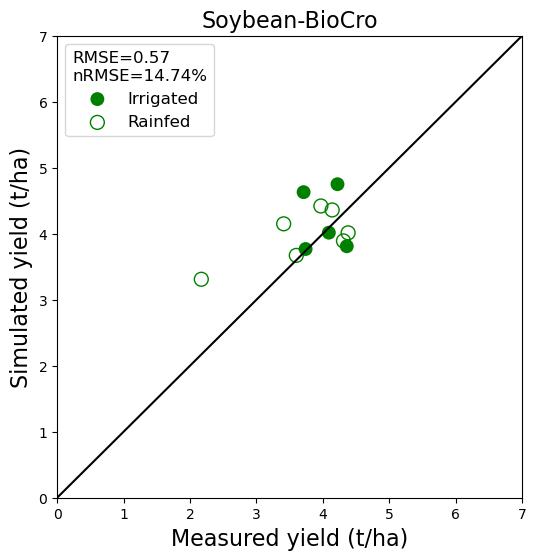

In [3]:
# BioCro — Soybean
plot_yield_comparison(CSV_SOYBEAN, 'Soybean-BioCro', 'Soybean-BioCro',
                      color='g', xlim=7, ylim=7)

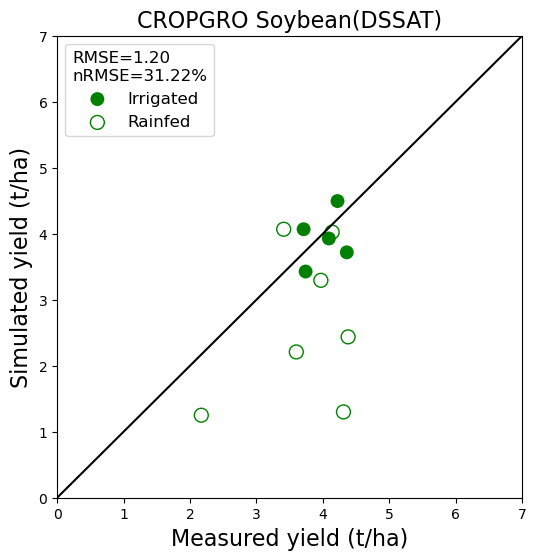

In [4]:
# CSM-CROPGRO — Soybean
plot_yield_comparison(CSV_SOYBEAN, 'CROPGRO-Soybean yield', 'CROPGRO Soybean(DSSAT)',
                      color='g', xlim=7, ylim=7)

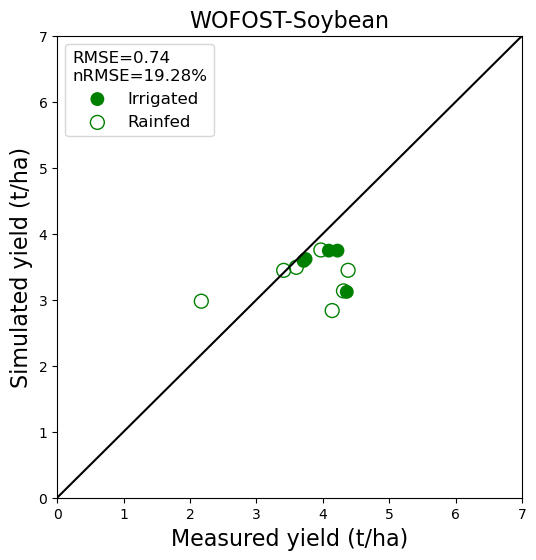

In [5]:
# WOFOST — Soybean
plot_yield_comparison(CSV_SOYBEAN, 'WOFOST', 'WOFOST-Soybean',
                      color='g', xlim=7, ylim=7)

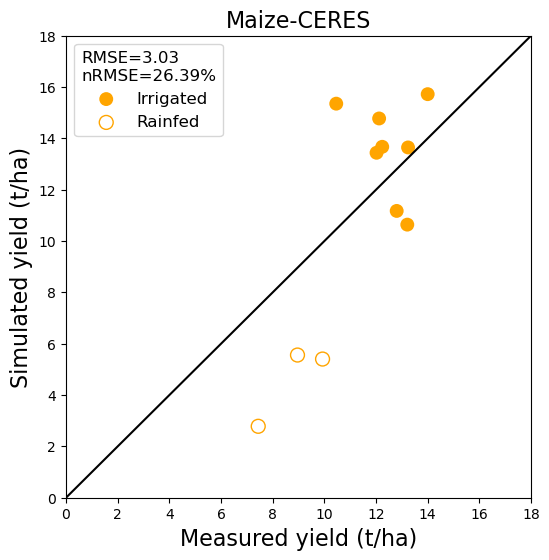

In [ ]:
# CSM — Maize
plot_yield_comparison(CSV_MAIZE, 'CERES-Maize', 'Maize-CERES',
                      color='orange', xlim=18, ylim=18)

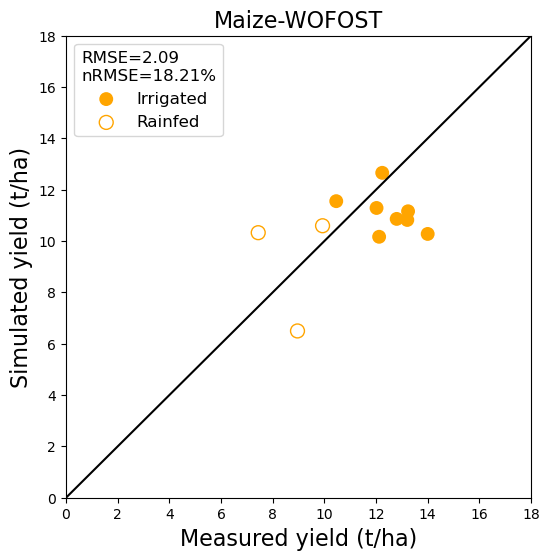

In [7]:
# WOFOST — Maize
plot_yield_comparison(CSV_MAIZE, 'WOFOST', 'Maize-WOFOST',
                      color='orange', xlim=18, ylim=18)